# Querying Chemical Databases

In earlier notebooks we worked with molecular representations (SMILES, fingerprints) and
built predictive models from curated datasets. But where do those datasets come from in
the first place? In practice, a chemist or data scientist begins with a list of compound
names, CAS numbers, or other identifiers and must **programmatically** retrieve
structural information and computed properties from public databases before any modelling
can begin.

This notebook teaches you how to query the two most important freely-available chemical
databases — **PubChem** and the **NCI Chemical Identifier Resolver (CIR)** — using
nothing more than Python's `requests` library and well-formed URLs.

## Learning Objectives

By the end of this notebook you will be able to:

- Understand PubChem as both a website and a programmatic data service.
- Construct PUG-REST API URLs to retrieve compound identifiers, properties, and images.
- Use the NCI Chemical Identifier Resolver (CIR) as an alternative lookup service.
- Build reusable Python helper functions with error handling and rate limiting.
- Enrich a molecular dataset by programmatically retrieving properties.
- Combine API-retrieved data with RDKit-computed descriptors.

## Prerequisites

- **Notebook 03 of this module** — Molecular representations and RDKit basics.
- Basic Python: functions, dictionaries, the `requests` library.
- An internet connection (cells that call external APIs are clearly marked).

### Setup

The cell below imports all required packages and applies the course plotting style.

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q rdkit-pypi")

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from urllib.parse import quote_plus
from IPython.display import Image, display

try:
    from rdkit import Chem
    from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors

    HAS_RDKIT = True
except ImportError:
    HAS_RDKIT = False
    print("RDKit not installed — molecular drawing cells will be skipped.")

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    PALETTE,
    SALMON,
    EMERALD,
    PERIWINKLE,
    CYAN,
    ORCHID,
    GOLD,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1 Why Programmatic Database Access?

Chemists routinely need to look up information about compounds:

| Information needed             | Example                 |
|--------------------------------|-------------------------|
| IUPAC name                     | *N,N*-dimethylbiguanide |
| CAS registry number            | 657-24-9                |
| Canonical SMILES               | `CN(C)C(=N)NC(=N)N`     |
| Molecular weight               | 129.164 g/mol           |
| LogP                           | −1.4                    |
| Hydrogen-bond donors/acceptors | 3 / 5                   |

Doing this manually on a web browser is perfectly fine when you have ten compounds.
When you have **500** — or when you need to repeat the enrichment every time a
dataset is updated — manual lookup becomes untenable.

**PubChem** (maintained by the National Center for Biotechnology Information, NCBI)
holds over **115 million** unique chemical structures with rich annotation covering
computed properties, bioassay results, patent references, and safety data.
Crucially, all of this information is queryable through a well-documented
**REST API** called **PUG-REST** (Power User Gateway).

### What is a REST API?

REST (*Representational State Transfer*) is an architectural style where data is
accessed by sending standard HTTP requests (the same kind your browser sends)
to structured URLs. For example, to retrieve the molecular weight of aspirin
from PubChem, you simply visit a URL like:

```
https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/aspirin/property/MolecularWeight/TXT
```

The server responds with plain text containing the answer. No authentication tokens,
no database credentials, no installation — just a URL.

In Python we use the `requests` library to send these HTTP requests and parse the
responses. The pattern is always the same:

1. **Construct the URL** from the compound identifier and the information you want.
2. **Send a GET request** with `requests.get(url)`.
3. **Check the response status** (200 = success, 404 = not found, etc.).
4. **Parse the response body** (plain text, JSON, or binary image data).

---

## 2 PubChem PUG-REST Basics

Every PUG-REST URL follows a four-part template:

$$
\underbrace{\texttt{https://pubchem.ncbi.nlm.nih.gov/rest/pug}}_{\text{base}}
\;/\;
\underbrace{\texttt{compound/\{id\_type\}/\{value\}}}_{\text{input}}
\;/\;
\underbrace{\texttt{\{operation\}}}_{\text{what to retrieve}}
\;/\;
\underbrace{\texttt{\{format\}}}_{\text{output format}}
$$

### Input identifier types

| `id_type`  | Meaning                     | Example `value`               |
|------------|-----------------------------|-------------------------------|
| `name`     | Common or trade name        | `metformin`                   |
| `cid`      | PubChem Compound ID         | `4091`                        |
| `smiles`   | SMILES string (URL-encoded) | `CN(C)C(=N)NC(=N)N`           |
| `inchikey` | InChIKey hash               | `BQJCRHHNABKAKU-UHFFFAOYSA-N` |

### Common operations

| Operation               | What it returns                               |
|-------------------------|-----------------------------------------------|
| `cids`                  | The PubChem Compound ID(s) matching the input |
| `property/PropertyName` | Specific computed properties                  |
| `synonyms`              | All known synonyms/trade names                |
| `PNG`                   | A 2D structure image                          |

### Output formats

`JSON`, `TXT` (plain text), `CSV`, `PNG` (binary image), `SDF`.

### Rate limits

PubChem enforces a soft rate limit of **5 requests per second**. Exceeding this
will result in HTTP 503 errors and may temporarily block your IP. **Always add
a small delay** (at least 0.2 seconds) between consecutive requests. We will
use `time.sleep(0.25)` throughout this notebook.

### 2.1 First query — resolving a drug name to a CID

Let us start with the simplest possible query: given the name **metformin**
(the world's most widely prescribed oral diabetes medication), retrieve its
PubChem Compound ID (CID). The CID is PubChem's unique integer identifier
for each compound and is the key we will use for all subsequent lookups.

> **Note:** This cell makes an internet request to PubChem.

In [2]:
# --- Internet access required ---
BASE_URL = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

url = f"{BASE_URL}/compound/name/metformin/cids/TXT"
print(f"Request URL:\n  {url}\n")

try:
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    metformin_cid = int(resp.text.strip())
    print(f"Metformin CID: {metformin_cid}")
except requests.RequestException as e:
    print(f"Request failed: {e}")
    metformin_cid = 4091  # fallback
    print(f"Using known fallback CID: {metformin_cid}")

Request URL:
  https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/metformin/cids/TXT

Metformin CID: 4091


### 2.2 Retrieving properties from a CID

Now that we have metformin's CID, we can ask PubChem for specific computed
properties. PUG-REST allows you to request multiple properties in a single
call by separating them with commas. We request the canonical SMILES, the
IUPAC name, the molecular weight, and the XLogP (a computed octanol-water
partition coefficient).

We request the response in **JSON** format this time so that we get a
structured dictionary rather than a flat text string.

In [ ]:
# --- Internet access required ---
time.sleep(0.25)  # rate limiting

props = "CanonicalSMILES,IUPACName,MolecularWeight,XLogP"
url = f"{BASE_URL}/compound/cid/{metformin_cid}/property/{props}/JSON"

try:
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    record = data["PropertyTable"]["Properties"][0]

    print("Metformin properties from PubChem:")
    for key, val in record.items():
        print(f"  {key:25s} {val}")
except requests.RequestException as e:
    print(f"Request failed: {e}")

Metformin properties from PubChem:
  CID                       4091
  MolecularWeight           129.16
  ConnectivitySMILES        CN(C)C(=N)N=C(N)N
  IUPACName                 3-(diaminomethylidene)-1,1-dimethylguanidine
  XLogP                     -1.3


The JSON response wraps the results in a `PropertyTable → Properties` list.
Each entry is a dictionary with the CID and the requested property values.
Notice that PubChem returns the **canonical SMILES** — a unique, normalised
string representation of the molecular graph without stereochemistry
information. We will discuss the distinction between canonical and isomeric
SMILES in Section 4.

---

## 3 Building Robust Helper Functions

Repeating the same URL-construction and error-handling code in every cell
would be tedious and error-prone. Instead, we encapsulate all PubChem
interactions in a **`PubChemClient` class**.

Key design decisions:

1. **Rate limiting is built-in.** The client tracks the timestamp of the
   last request and automatically sleeps if calls arrive too quickly.
2. **Timeouts and error handling.** Every request has a 30-second timeout
   and calls `raise_for_status()` to convert HTTP errors into Python
   exceptions.
3. **A unified `lookup()` method.** Given any compound name, this method
   resolves the CID and then retrieves a comprehensive summary in a
   single call.
4. **Image retrieval.** The `cid_to_png()` method returns raw PNG bytes
   that can be displayed inline in the notebook.

The cell below defines the class; subsequent cells demonstrate its use.

In [ ]:
class PubChemClient:
    """Lightweight client for the PubChem PUG-REST API."""

    BASE = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

    def __init__(self, delay: float = 0.25):
        self.delay = delay
        self._last_call = 0.0

    # ------------------------------------------------------------------ #
    # internal GET with rate limiting
    # ------------------------------------------------------------------ #
    def _get(self, path: str, fmt: str = "TXT"):
        """Send a GET request to PUG-REST with automatic rate limiting."""
        elapsed = time.time() - self._last_call
        if elapsed < self.delay:
            time.sleep(self.delay - elapsed)
        url = f"{self.BASE}/{path}"
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        self._last_call = time.time()
        if fmt == "JSON":
            return resp.json()
        elif fmt == "bytes":
            return resp.content
        return resp.text.strip()

    # ------------------------------------------------------------------ #
    # identifier lookups
    # ------------------------------------------------------------------ #
    def name_to_cid(self, name: str) -> int:
        """Resolve a compound name to its PubChem CID."""
        text = self._get(f"compound/name/{quote_plus(name)}/cids/TXT")
        return int(text.splitlines()[0])

    def cid_to_smiles(self, cid: int, isomeric: bool = True) -> str:
        """Return SMILES for a CID. Use isomeric=True for stereo info."""
        prop = "IsomericSMILES" if isomeric else "CanonicalSMILES"
        return self._get(f"compound/cid/{cid}/property/{prop}/TXT")

    def cid_to_iupac(self, cid: int) -> str:
        """Return the IUPAC name for a CID."""
        return self._get(f"compound/cid/{cid}/property/IUPACName/TXT")

    def cid_to_inchikey(self, cid: int) -> str:
        """Return the InChIKey for a CID."""
        return self._get(f"compound/cid/{cid}/property/InChIKey/TXT")

    # ------------------------------------------------------------------ #
    # multi-property retrieval
    # ------------------------------------------------------------------ #
    def cid_to_properties(
        self,
        cid: int,
        fields: tuple = (
            "MolecularWeight",
            "XLogP",
            "HBondDonorCount",
            "HBondAcceptorCount",
            "TPSA",
        ),
    ) -> dict:
        """Return a dict of computed properties for a CID."""
        field_str = ",".join(fields)
        data = self._get(f"compound/cid/{cid}/property/{field_str}/JSON", fmt="JSON")
        return data["PropertyTable"]["Properties"][0]

    # ------------------------------------------------------------------ #
    # image retrieval
    # ------------------------------------------------------------------ #
    def cid_to_png(self, cid: int, size: int = 300) -> bytes:
        """Return PNG image bytes for a CID."""
        return self._get(
            f"compound/cid/{cid}/PNG?image_size={size}x{size}",
            fmt="bytes",
        )

    # ------------------------------------------------------------------ #
    # unified lookup
    # ------------------------------------------------------------------ #
    def lookup(self, query: str) -> dict:
        """Resolve a compound name to a summary dict with CID, SMILES,
        IUPAC name, InChIKey, and standard computed properties."""
        cid = self.name_to_cid(query)
        props = self.cid_to_properties(
            cid,
            fields=(
                "IsomericSMILES",
                "CanonicalSMILES",
                "IUPACName",
                "InChIKey",
                "MolecularWeight",
                "XLogP",
                "HBondDonorCount",
                "HBondAcceptorCount",
                "TPSA",
            ),
        )
        props["Name"] = query
        return props


pc = PubChemClient()
print("PubChemClient ready.")

PubChemClient ready.


### 3.1 Testing the client — losartan

Losartan is an angiotensin II receptor blocker (ARB) used to treat
hypertension. Let us use the `lookup()` method to retrieve a comprehensive
summary.

> **Note:** This cell makes internet requests to PubChem.

In [5]:
# --- Internet access required ---
try:
    losartan = pc.lookup("losartan")
    print("Losartan summary:")
    for k, v in losartan.items():
        print(f"  {k:25s} {v}")
except requests.RequestException as e:
    print(f"Could not reach PubChem: {e}")

Losartan summary:
  CID                       3961
  MolecularWeight           422.9
  SMILES                    CCCCC1=NC(=C(N1CC2=CC=C(C=C2)C3=CC=CC=C3C4=NNN=N4)CO)Cl
  ConnectivitySMILES        CCCCC1=NC(=C(N1CC2=CC=C(C=C2)C3=CC=CC=C3C4=NNN=N4)CO)Cl
  InChIKey                  PSIFNNKUMBGKDQ-UHFFFAOYSA-N
  IUPACName                 [2-butyl-5-chloro-3-[[4-[2-(2H-tetrazol-5-yl)phenyl]phenyl]methyl]imidazol-4-yl]methanol
  XLogP                     4.3
  TPSA                      92.5
  HBondDonorCount           2
  HBondAcceptorCount        5
  Name                      losartan


### 3.2 Looking up multiple drugs

A more realistic scenario: we have a short list of drugs and want a
comparison table. The cell below queries PubChem for five compounds and
assembles the results into a pandas DataFrame. Notice how the built-in
rate limiting in `PubChemClient` ensures we never exceed PubChem's
request limit.

> **Note:** This cell makes multiple internet requests.

In [ ]:
# --- Internet access required ---
drug_names = ["metformin", "losartan", "tamoxifen", "dexamethasone", "sildenafil"]

records = []
for name in drug_names:
    try:
        info = pc.lookup(name)
        records.append(info)
        print(f"  ✓ {name} (CID {info['CID']})")
    except requests.RequestException as e:
        print(f"  ✗ {name}: {e}")

if records:
    df_drugs = pd.DataFrame(records)
    display_cols = [
        "Name",
        "CID",
        "MolecularWeight",
        "XLogP",
        "HBondDonorCount",
        "HBondAcceptorCount",
        "TPSA",
    ]
    display(df_drugs[[c for c in display_cols if c in df_drugs.columns]])

  ✓ metformin (CID 4091)
  ✓ losartan (CID 3961)
  ✓ tamoxifen (CID 2733526)
  ✓ dexamethasone (CID 5743)
  ✓ sildenafil (CID 135398744)


,Name,CID,MolecularWeight,XLogP,HBondDonorCount,HBondAcceptorCount,TPSA
0,metformin,4091,129.16,-1.3,3,1,91.5
1,losartan,3961,422.9,4.3,2,5,92.5
2,tamoxifen,2733526,371.5,7.1,0,2,12.5
3,dexamethasone,5743,392.5,1.9,3,6,94.8
4,sildenafil,135398744,474.6,1.5,1,8,118.0


Even with just five compounds, you can already see meaningful chemical
diversity: metformin is tiny (MW ~129) and very hydrophilic (negative XLogP),
while tamoxifen is large and lipophilic (XLogP > 5). These differences
directly affect how these drugs are absorbed, distributed, and eliminated
in the body.

---

## 4 Canonical vs Isomeric SMILES

SMILES strings come in two standard flavours, and the distinction matters
for any serious cheminformatics work:

- **Canonical SMILES** — a unique, normalised representation of the
  molecular graph. It encodes connectivity and bond orders but
  **discards stereochemistry**. Two molecules that differ only in the
  spatial arrangement of their atoms (enantiomers, *E*/*Z* isomers) will
  have the **same** canonical SMILES.

- **Isomeric SMILES** — extends the canonical form with stereochemical
  markers: `@`/`@@` for tetrahedral chirality and `/`/`\\` for
  double-bond geometry. Isotopic labels (e.g., `[2H]` for deuterium)
  are also included.

### Why does this matter?

Some molecules have identical 2D connectivity but profoundly different
biological activity depending on their 3D configuration. The most
notorious example is **thalidomide**: one enantiomer is a sedative, the
other is teratogenic.

**Omeprazole** (a proton-pump inhibitor used for acid reflux) provides
another instructive case. It contains a **chiral sulfoxide** centre.
The racemic mixture is sold as omeprazole; the pure (*S*)-enantiomer is
marketed separately as **esomeprazole** (Nexium). Let us see the
difference in their SMILES representations.

The cell below retrieves both canonical and isomeric SMILES for omeprazole
and esomeprazole from PubChem and compares them.

> **Note:** This cell makes internet requests to PubChem.

In [ ]:
# --- Internet access required ---
try:
    ome_cid = pc.name_to_cid("omeprazole")
    eso_cid = pc.name_to_cid("esomeprazole")

    ome_canonical = pc.cid_to_smiles(ome_cid, isomeric=False)
    ome_isomeric = pc.cid_to_smiles(ome_cid, isomeric=True)
    eso_canonical = pc.cid_to_smiles(eso_cid, isomeric=False)
    eso_isomeric = pc.cid_to_smiles(eso_cid, isomeric=True)

    print("Omeprazole (racemic):")
    print(f"  Canonical:  {ome_canonical}")
    print(f"  Isomeric:   {ome_isomeric}")
    print()
    print("Esomeprazole (S-enantiomer):")
    print(f"  Canonical:  {eso_canonical}")
    print(f"  Isomeric:   {eso_isomeric}")
    print()
    print(f"Canonical SMILES identical? {ome_canonical == eso_canonical}")
    print(f"Isomeric SMILES identical?  {ome_isomeric == eso_isomeric}")
except requests.RequestException as e:
    print(f"Could not reach PubChem: {e}")

Omeprazole (racemic):
  Canonical:  CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=C(N2)C=C(C=C3)OC
  Isomeric:   CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=C(N2)C=C(C=C3)OC

Esomeprazole (S-enantiomer):
  Canonical:  CC1=CN=C(C(=C1OC)C)CS(=O)C2=NC3=C(N2)C=C(C=C3)OC
  Isomeric:   CC1=CN=C(C(=C1OC)C)C[S@](=O)C2=NC3=C(N2)C=C(C=C3)OC

Canonical SMILES identical? True
Isomeric SMILES identical?  False


The canonical SMILES are identical (or nearly so) because they encode the
same molecular graph. The isomeric SMILES differ because esomeprazole
specifies the (*S*)-configuration at the sulfoxide centre.

**Rule of thumb:** always store and use **isomeric SMILES** unless you have
a specific reason to discard stereochemistry (e.g., when building
2D-fingerprint models that are chirality-agnostic).

---

## 5 NCI Chemical Identifier Resolver (CIR)

The **Chemical Identifier Resolver** (CIR) is a web service maintained by
the National Cancer Institute (NCI) at NIH. It provides a complementary
lookup capability to PubChem, with a particularly useful feature:
**CAS number resolution**.

While PubChem treats CAS numbers as synonyms (you can search for them
via the `name` endpoint), CIR provides a more direct and sometimes more
reliable mapping from CAS numbers to structures.

### URL structure

```
https://cactus.nci.nih.gov/chemical/structure/{input}/{output}
```

where `{input}` is a compound name, CAS number, SMILES, or InChIKey, and
`{output}` specifies what you want back:

| Output type   | Description              |
|---------------|--------------------------|
| `smiles`      | SMILES string            |
| `stdinchikey` | Standard InChIKey        |
| `names`       | Known names/synonyms     |
| `cas`         | CAS registry number(s)   |
| `mw`          | Molecular weight         |
| `formula`     | Molecular formula        |
| `image`       | 2D structure image (PNG) |

### 5.1 A CIR helper function

The cell below defines a simple helper function for querying CIR. Unlike
PubChem, CIR does not enforce strict rate limits, but we still add a small
delay to be a good citizen.

In [8]:
CIR_BASE = "https://cactus.nci.nih.gov/chemical/structure"


def cir_resolve(query: str, output_type: str = "smiles") -> str:
    """Resolve a chemical identifier using the NCI CIR service.

    Parameters
    ----------
    query : str
        Compound name, CAS number, SMILES, or InChIKey.
    output_type : str
        What to retrieve: 'smiles', 'stdinchikey', 'cas', 'mw',
        'formula', 'names'.

    Returns
    -------
    str
        The resolved value, or raises an exception on failure.
    """
    url = f"{CIR_BASE}/{quote_plus(query)}/{output_type}"
    time.sleep(0.25)  # polite delay
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return resp.text.strip()


print("cir_resolve() defined.")

cir_resolve() defined.


### 5.2 Getting a CAS number for dexamethasone

Dexamethasone is a corticosteroid used to treat inflammation and certain
cancers. Let us retrieve its CAS number and molecular formula via CIR.

> **Note:** This cell makes internet requests to the NCI CIR service.

In [9]:
# --- Internet access required ---
try:
    dexa_cas = cir_resolve("dexamethasone", "cas")
    dexa_formula = cir_resolve("dexamethasone", "formula")
    dexa_mw = cir_resolve("dexamethasone", "mw")

    print("Dexamethasone via NCI CIR:")
    print(f"  CAS number:       {dexa_cas.splitlines()[0]}")
    print(f"  Molecular formula: {dexa_formula}")
    print(f"  Molecular weight:  {dexa_mw} g/mol")
except requests.RequestException as e:
    print(f"CIR request failed: {e}")

Dexamethasone via NCI CIR:
  CAS number:       137098-19-2
  Molecular formula: C22H29FO5
  Molecular weight:  392.4665 g/mol


### 5.3 Cross-validating PubChem and CIR

When working with chemical data, it is good practice to **cross-validate**
identifiers from different sources. The InChIKey is the ideal identifier
for this purpose because it is a standardised hash of the molecular
structure — two services should return the **same InChIKey** for the same
compound.

The cell below retrieves InChIKeys from both PubChem and CIR for three
drugs and checks whether they agree.

> **Note:** This cell makes internet requests to both PubChem and CIR.

In [10]:
# --- Internet access required ---
validation_drugs = ["metformin", "sildenafil", "montelukast"]

print(f"{'Drug':20s} {'PubChem InChIKey':30s} {'CIR InChIKey':30s} {'Match'}")
print("-" * 95)

for name in validation_drugs:
    try:
        cid = pc.name_to_cid(name)
        pc_key = pc.cid_to_inchikey(cid)
    except requests.RequestException:
        pc_key = "(PubChem error)"

    try:
        cir_key = cir_resolve(name, "stdinchikey")
    except requests.RequestException:
        cir_key = "(CIR error)"

    # CIR returns "InChIKey=..." prefix; strip it for comparison
    cir_key_clean = cir_key.replace("InChIKey=", "").strip().splitlines()[0]
    match = "YES" if pc_key == cir_key_clean else "no"
    print(f"{name:20s} {pc_key:30s} {cir_key_clean:30s} {match}")

Drug                 PubChem InChIKey               CIR InChIKey                   Match
-----------------------------------------------------------------------------------------------
metformin            XZWYZXLIPXDOLR-UHFFFAOYSA-N    OETHQSJEHLVLGH-UHFFFAOYSA-N    no
sildenafil           BNRNXUUZRGQAQC-UHFFFAOYSA-N    BNRNXUUZRGQAQC-UHFFFAOYSA-N    YES
montelukast          UCHDWCPVSPXUMX-TZIWLTJVSA-N    UCHDWCPVSPXUMX-TZIWLTJVSA-N    YES


If both services are working correctly, the InChIKeys should match for all
three compounds. Discrepancies could indicate that one service resolved to
a salt form while the other resolved to the free base, or that the name is
ambiguous. We will discuss these edge cases in Section 7.

---

## 6 Enriching a Molecular Dataset

We now combine everything we have learned into a realistic workflow.
Suppose we are beginning a study on **anti-hypertensive drugs** and want
to build a dataset with structural information and computed properties
for downstream analysis (e.g., QSAR modelling, clustering, or ML
prediction as covered in Notebooks 04 and 08).

**Starting point:** a list of 12 drug names, chosen to span different
pharmacological classes (ARBs, ACE inhibitors, calcium channel blockers,
beta-blockers, diuretics).

**Goal:** a pandas DataFrame with SMILES, molecular weight, XLogP,
hydrogen-bond counts, TPSA, and (if RDKit is available) additional
computed descriptors.

### 6.1 Define the compound list

We start by defining our target compounds. No API calls yet.

In [11]:
antihypertensives = [
    "losartan",
    "amlodipine",
    "lisinopril",
    "metoprolol",
    "valsartan",
    "hydrochlorothiazide",
    "enalapril",
    "nifedipine",
    "ramipril",
    "candesartan",
    "bisoprolol",
    "diltiazem",
]

print(f"Target compounds: {len(antihypertensives)}")
for i, name in enumerate(antihypertensives, 1):
    print(f"  {i:2d}. {name}")

Target compounds: 12
   1. losartan
   2. amlodipine
   3. lisinopril
   4. metoprolol
   5. valsartan
   6. hydrochlorothiazide
   7. enalapril
   8. nifedipine
   9. ramipril
  10. candesartan
  11. bisoprolol
  12. diltiazem


### 6.2 Query PubChem for SMILES and properties

The cell below iterates over the compound list, calling `pc.lookup()` for
each drug. Progress is printed as we go. Failed lookups are recorded but
do not halt the loop.

> **Note:** This cell makes ~24 internet requests (2 per compound: one to
> resolve the name, one to fetch properties). With the 0.25-second delay,
> expect it to take about 10-15 seconds.

In [12]:
# --- Internet access required ---
enriched_records = []
failed = []

for name in antihypertensives:
    try:
        info = pc.lookup(name)
        enriched_records.append(info)
        mw = info.get("MolecularWeight", "?")
        print(f"  ✓ {name:25s} MW={mw}")
    except requests.RequestException as e:
        failed.append((name, str(e)))
        print(f"  ✗ {name:25s} FAILED: {e}")

print(f"\nSucceeded: {len(enriched_records)} / {len(antihypertensives)}")
if failed:
    print(f"Failed: {[f[0] for f in failed]}")

  ✓ losartan                  MW=422.9
  ✓ amlodipine                MW=408.9
  ✓ lisinopril                MW=405.5
  ✓ metoprolol                MW=267.36
  ✓ valsartan                 MW=435.5
  ✓ hydrochlorothiazide       MW=297.7
  ✓ enalapril                 MW=376.4
  ✓ nifedipine                MW=346.3
  ✓ ramipril                  MW=416.5
  ✓ candesartan               MW=440.5
  ✓ bisoprolol                MW=325.4
  ✓ diltiazem                 MW=414.5

Succeeded: 12 / 12


### 6.3 Compute additional descriptors with RDKit

PubChem provides a good set of pre-computed properties, but for many
cheminformatics workflows we need descriptors that PubChem does not
expose through PUG-REST. RDKit can compute hundreds of molecular
descriptors from a SMILES string.

Here we add three descriptors that are particularly useful for
drug-likeness assessment:

- **NumRings** — the total number of rings in the molecule.
- **NumRotatableBonds** — bonds that allow free rotation, affecting
  molecular flexibility and oral bioavailability.
- **FractionCSP3** — the fraction of carbon atoms that are sp3-hybridised
  (tetrahedral). Higher values indicate more three-dimensionality,
  which correlates with clinical success rates.

In [13]:
if HAS_RDKIT and enriched_records:
    for rec in enriched_records:
        smi = rec.get("IsomericSMILES") or rec.get("CanonicalSMILES", "")
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            rec["NumRings"] = rdMolDescriptors.CalcNumRings(mol)
            rec["NumRotatableBonds"] = Descriptors.NumRotatableBonds(mol)
            rec["FractionCSP3"] = round(Descriptors.FractionCSP3(mol), 3)
        else:
            rec["NumRings"] = None
            rec["NumRotatableBonds"] = None
            rec["FractionCSP3"] = None
    print("RDKit descriptors added: NumRings, NumRotatableBonds, FractionCSP3")
elif not HAS_RDKIT:
    print("RDKit not available — skipping descriptor computation.")
else:
    print("No records to process.")

RDKit descriptors added: NumRings, NumRotatableBonds, FractionCSP3


### 6.4 The enriched DataFrame

We now assemble and display the complete dataset. This is exactly the kind
of table you would save to a CSV file and use as input for the QSAR and
machine-learning workflows covered in Notebooks 04 and 08.

In [ ]:
if enriched_records:
    df_enriched = pd.DataFrame(enriched_records)

    # Select and reorder columns for display
    show_cols = [
        "Name",
        "CID",
        "MolecularWeight",
        "XLogP",
        "HBondDonorCount",
        "HBondAcceptorCount",
        "TPSA",
    ]
    if HAS_RDKIT:
        show_cols += ["NumRings", "NumRotatableBonds", "FractionCSP3"]
    show_cols = [c for c in show_cols if c in df_enriched.columns]

    # Convert MW to float for sorting
    df_enriched["MolecularWeight"] = pd.to_numeric(
        df_enriched["MolecularWeight"], errors="coerce"
    )
    display(df_enriched[show_cols].sort_values("MolecularWeight", ascending=False))
else:
    print("No data to display (API calls may have failed).")

,Name,CID,MolecularWeight,XLogP,HBondDonorCount,HBondAcceptorCount,TPSA,NumRings,NumRotatableBonds,FractionCSP3
9,candesartan,2541,440.50,4.1,2,7,119.0,0,0,0.0
4,valsartan,60846,435.50,4.4,2,6,112.0,0,0,0.0
0,losartan,3961,422.90,4.3,2,5,92.5,0,0,0.0
8,ramipril,5362129,416.50,1.4,2,6,95.9,0,0,0.0
11,diltiazem,39186,414.50,3.1,0,6,84.4,0,0,0.0
1,amlodipine,2162,408.90,3.0,2,7,99.9,0,0,0.0
2,lisinopril,5362119,405.50,-2.9,4,7,133.0,0,0,0.0
6,enalapril,5388962,376.40,-0.1,2,6,95.9,0,0,0.0
7,nifedipine,4485,346.30,2.2,1,7,110.0,0,0,0.0
10,bisoprolol,2405,325.40,1.9,2,5,60.0,0,0,0.0


### 6.5 Comparing molecular weights

A simple horizontal bar chart provides an immediate visual comparison.
We sort the drugs by molecular weight so that the heaviest molecules
appear at the top. This kind of plot is useful for quickly identifying
outliers or compounds that may violate Lipinski's Rule of Five
(MW > 500 g/mol is a warning flag for oral bioavailability).

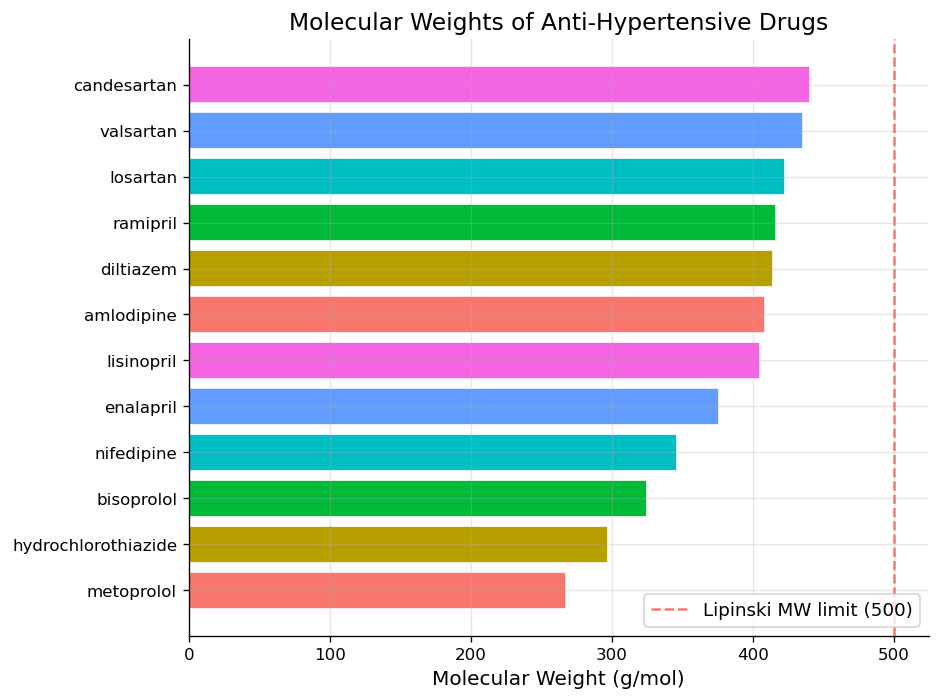

In [ ]:
if enriched_records:
    df_plot = (
        df_enriched[["Name", "MolecularWeight"]].dropna().sort_values("MolecularWeight")
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(df_plot))]
    ax.barh(
        df_plot["Name"], df_plot["MolecularWeight"], color=colors, edgecolor="white"
    )

    # Lipinski threshold
    ax.axvline(
        500,
        color=SALMON,
        linestyle="--",
        linewidth=1.5,
        label="Lipinski MW limit (500)",
    )

    ax.set_xlabel("Molecular Weight (g/mol)")
    ax.set_title("Molecular Weights of Anti-Hypertensive Drugs")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

---

## 7 Handling Errors and Edge Cases

Real-world chemical database queries are messy. Several common pitfalls
can trip up an automated pipeline:

### 7.1 Names that do not resolve

Typos, uncommon abbreviations, or names for mixtures/formulations
(rather than single compounds) may return a 404 error from PubChem.
Your code should **always** handle this gracefully.

### 7.2 Missing properties

Not all CIDs have every property computed. For example, XLogP may be
`None` for very large molecules or inorganic compounds. Always check
for missing values before using a property in calculations.

### 7.3 Salts vs free base

Searching for **"losartan potassium"** may yield a different CID than
**"losartan"** because the salt form is registered as a separate
compound. The free base is typically what you want for structural
analysis, but the salt form is what is actually administered clinically.
Be explicit about which form you need.

The cell below demonstrates graceful error handling by attempting to look
up a non-existent compound name. The `try/except` block catches the HTTP
error and prints an informative message instead of crashing.

> **Note:** This cell makes an internet request that is *expected* to fail.

In [16]:
# --- Internet access required ---
# Deliberately query a non-existent compound
fake_names = ["xyzzyplatin", "losartan", "unobtanium-42"]

for name in fake_names:
    try:
        cid = pc.name_to_cid(name)
        print(f"  ✓ '{name}' resolved to CID {cid}")
    except requests.HTTPError as e:
        status = e.response.status_code if e.response is not None else "?"
        print(f"  ✗ '{name}' failed with HTTP {status} — compound not found")
    except requests.RequestException as e:
        print(f"  ✗ '{name}' failed: {e}")

  ✗ 'xyzzyplatin' failed with HTTP 404 — compound not found
  ✓ 'losartan' resolved to CID 3961
  ✗ 'unobtanium-42' failed with HTTP 404 — compound not found


The fictitious names return HTTP 404 (Not Found), while the real drug
resolves successfully. In a production pipeline, you would **log** the
failed compounds to a separate list and either fix the names manually
or try alternative identifiers (CAS numbers, InChIKeys) through CIR.

**Best practice checklist for robust chemical data retrieval:**

1. Always wrap API calls in `try/except`.
2. Log which compounds failed and why (HTTP status code, timeout, etc.).
3. Add rate-limiting delays between requests.
4. Validate results by cross-checking identifiers across services.
5. Be explicit about salt vs free-base forms.
6. Check for missing/null values before downstream analysis.

---

## Key Takeaways

- **PubChem PUG-REST** provides free, programmatic access to over 115 million
  compounds. URLs follow a simple four-part template:
  `base/compound/{id_type}/{value}/{operation}/{format}`.

- **Rate limiting is mandatory.** PubChem allows at most 5 requests per second.
  Build the delay into your helper functions so you never forget it.

- **The NCI Chemical Identifier Resolver (CIR)** is a valuable complement to
  PubChem, especially for CAS number lookups and cross-validation.

- **Canonical vs isomeric SMILES** is not a minor technicality — it determines
  whether your dataset preserves stereochemistry information that may be
  biologically critical. Always prefer isomeric SMILES unless you have a
  reason not to.

- **Robust error handling** (timeouts, HTTP error codes, missing properties,
  salt/free-base ambiguity) is essential for any automated data-retrieval
  pipeline.

- **Combining API data with RDKit descriptors** gives you a rich feature
  matrix that is ready for exploratory analysis, QSAR modelling, or
  machine-learning workflows.

In the next notebooks, we will use datasets built with exactly this
approach as input for predictive modelling and molecular design.

### Further Reading

- [PubChem PUG-REST documentation](https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest)
- [NCI Chemical Identifier Resolver](https://cactus.nci.nih.gov/chemical/structure)
- [PubChem PUG-REST tutorial](https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest-tutorial)
- [InChIKey specification (IUPAC)](https://www.inchi-trust.org/)

In [ ]:
cfg.save_gifs(clean=True)